# Analysis · Unified (Parts 1–6)

Consolidated analysis for the completed leave-one-dataset-out experiment. Runs after all folds are trained: result aggregation and confusion matrices, calibration, decision threshold optimization, Grad-CAM interpretability, statistical analysis with bootstrap confidence intervals, and the end-to-end clinical output. Requires a GPU session (several parts reload model checkpoints).

## Shared setup

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys, importlib
sys.path.insert(0,'/content/drive/MyDrive/Master Thesis/scope3')
import config; importlib.reload(config)
import pandas as pd, numpy as np, json, glob
from pathlib import Path
import torch
if 'training_lib' in sys.modules: importlib.reload(sys.modules['training_lib'])
import training_lib as T
device='cuda' if torch.cuda.is_available() else 'cpu'
manifest = T.prepare_local_data()
print('Device:', device, '| Manifest:', f'{len(manifest):,} rows')

Mounted at /content/drive
Copied array in 42s
Loaded array (61558, 224, 224) in 1s
Device: cuda | Manifest: 61,558 rows


# Part 1 · Evaluation — Result Aggregation and Confusion Matrices

## Result aggregation

In [3]:
files=sorted(glob.glob(str(config.RESULTS_DIR/'*.json')))
rows=[json.load(open(f)) for f in files]
allr=pd.DataFrame(rows)
if len(allr)==0: raise RuntimeError('No results yet.')
allr['kind']=np.where(allr['run_name'].str.startswith('ablation'),'ablation',
              np.where(allr['run_name'].str.startswith('single'),'single','lodo'))
print(f'Total runs: {len(allr)}')
allr.to_csv(str(config.RESULTS_DIR/'all_runs.csv'),index=False)
print(allr[['run_name','internal_acc5','external_acc5','external_qwk','gap']].to_string(index=False))

Total runs: 27
                     run_name  internal_acc5  external_acc5  external_qwk       gap
       ablation_A_naive_seed0       0.581989       0.273762      0.231676  0.308227
     ablation_B_sampler_seed0       0.566729       0.333575      0.343899  0.233154
   ablation_C_noiseloss_seed0       0.559850       0.345320      0.370454  0.214530
  ablation_D_curriculum_seed0       0.542964       0.362877      0.381448  0.180087
  ablation_E_domain_adv_seed0       0.538587       0.359608      0.372979  0.178979
ablation_F_direct5class_seed0       0.537586       0.359487      0.368737  0.178099
     ablation_G_ordinal_seed0       0.536836       0.373411      0.405584  0.163425
    ablation_H_combined_seed0       0.537211       0.374985      0.406608  0.162226
    fold1_test_mendeley_seed0       0.539212       0.337692      0.353525  0.201520
    fold1_test_mendeley_seed1       0.551470       0.358518      0.364253  0.192952
    fold1_test_mendeley_seed2       0.542464       0.382492  

## Leave-one-dataset-out summary

In [4]:
lodo=allr[allr['kind']=='lodo'].copy()
if len(lodo):
    lodo['fold']=lodo['run_name'].str.extract(r'(fold\d_test_\w+?)_seed')[0]
    s=lodo.groupby('fold').agg(internal=('internal_acc5','mean'),external=('external_acc5','mean'),
        external_std=('external_acc5','std'),qwk=('external_qwk','mean'),binary=('external_acc_binary','mean'),
        auc_oa=('external_auc_oa','mean'),gap=('gap','mean')).round(4)
    print(s.to_string())
    print(f'\nMean external: {lodo["external_acc5"].mean():.4f}  QWK: {lodo["external_qwk"].mean():.4f}  Gap: {lodo["gap"].mean():.4f}')
    s.to_csv(str(config.RESULTS_DIR/'lodo_fold_summary.csv'))
else: print('No LODO results yet.')

                     internal  external  external_std     qwk  binary  auc_oa     gap
fold                                                                                 
fold1_test_mendeley    0.5444    0.3596        0.0224  0.3748  0.6593  0.7692  0.1848
fold2_test_mrkr        0.5563    0.4820        0.0053  0.5247  0.7036  0.8053  0.0743
fold3_test_nhanes3     0.5360    0.6061        0.0074  0.6028  0.7788  0.8458 -0.0702
fold4_test_oai         0.5285    0.4858        0.0032  0.5325  0.7331  0.8067  0.0427

Mean external: 0.4673  QWK: 0.4917  Gap: 0.0735


## Confusion matrices

  scoring mendeley...
Downloading: "https://download.pytorch.org/models/convnext_large-ea097f82.pth" to /root/.cache/torch/hub/checkpoints/convnext_large-ea097f82.pth


100%|██████████| 755M/755M [00:03<00:00, 218MB/s]


  scoring mrkr...
  scoring nhanes3...
  scoring oai...


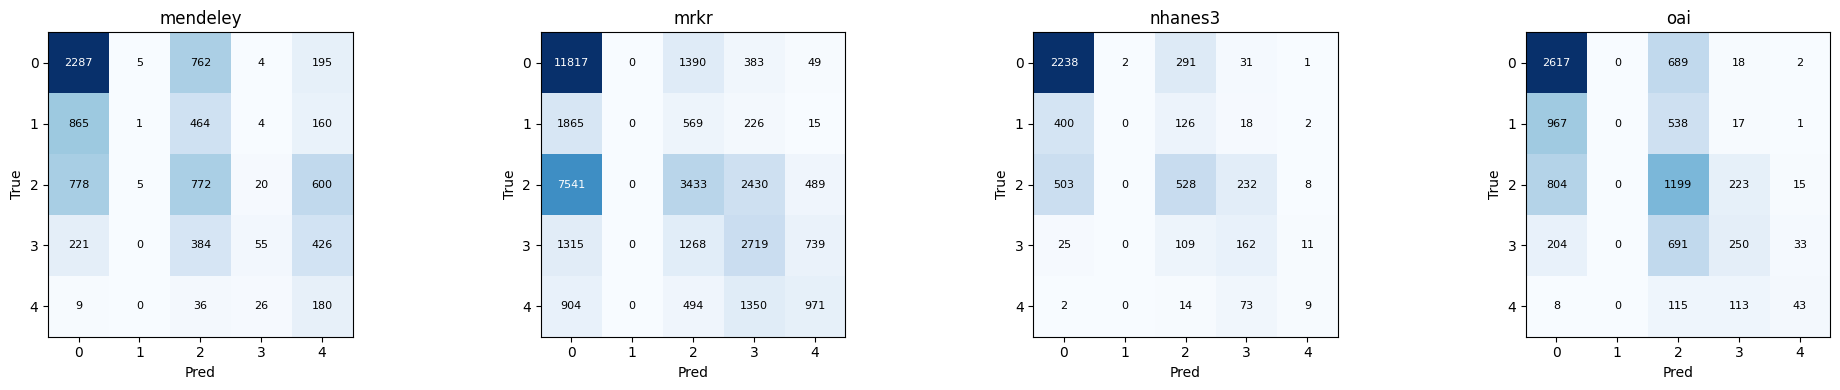

Saved: confusion_matrices.png


In [5]:
import torch, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
folds=list(config.LODO_FOLDS.items())
fig,axes=plt.subplots(1,len(folds),figsize=(5*len(folds),4))
if len(folds)==1: axes=[axes]
for ax,(fk,td) in zip(axes,folds):
    bp=config.CKPT_DIR/f'{fk}_seed0_best.pt'
    if not bp.exists(): ax.set_title(f'{td}: no ckpt'); ax.axis('off'); continue
    print(f'  scoring {td}...', flush=True)
    m=T.HierarchicalNet(config.NUM_CLASSES).to(device); T.load_ckpt(str(bp),m,None)
    te=manifest[manifest['dataset']==td].reset_index(drop=True)
    pr,_=T.predict_tta(m,te,device,use_tta=False)
    cm=confusion_matrix(te['kl_grade'].values,pr,labels=[0,1,2,3,4])
    ax.imshow(cm,cmap='Blues'); ax.set_title(td); ax.set_xlabel('Pred'); ax.set_ylabel('True')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    for i in range(5):
        for j in range(5): ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=8,color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.tight_layout(); plt.savefig(str(config.RESULTS_DIR/'confusion_matrices.png'),dpi=150,bbox_inches='tight'); plt.show()
print('Saved: confusion_matrices.png')

## Overfitting diagnostic

Reports the train–validation accuracy gap per run and plots learning curves; a sustained gap above 15 percentage points indicates overfitting.

run                                        train     val     gap  flag
ablation_A_naive_seed0                     0.560   0.582  -0.016  ok
ablation_B_sampler_seed0                   0.587   0.567   0.027  ok
ablation_C_noiseloss_seed0                 0.586   0.560   0.032  ok
ablation_D_curriculum_seed0                0.591   0.543   0.065  ok
ablation_E_domain_adv_seed0                0.589   0.539   0.066  ok
ablation_F_direct5class_seed0              0.585   0.538   0.068  ok
ablation_G_ordinal_seed0                   0.584   0.537   0.077  ok
ablation_H_combined_seed0                  0.584   0.537   0.077  ok
fold1_test_mendeley_seed0                  0.584   0.539   0.077  ok
fold1_test_mendeley_seed1                  0.582   0.551   0.051  ok
fold1_test_mendeley_seed2                  0.585   0.542   0.064  ok
fold2_test_mrkr_seed0                      0.547   0.552   0.013  ok
fold2_test_mrkr_seed1                      0.543   0.559   0.003  ok
fold2_test_mrkr_seed2           

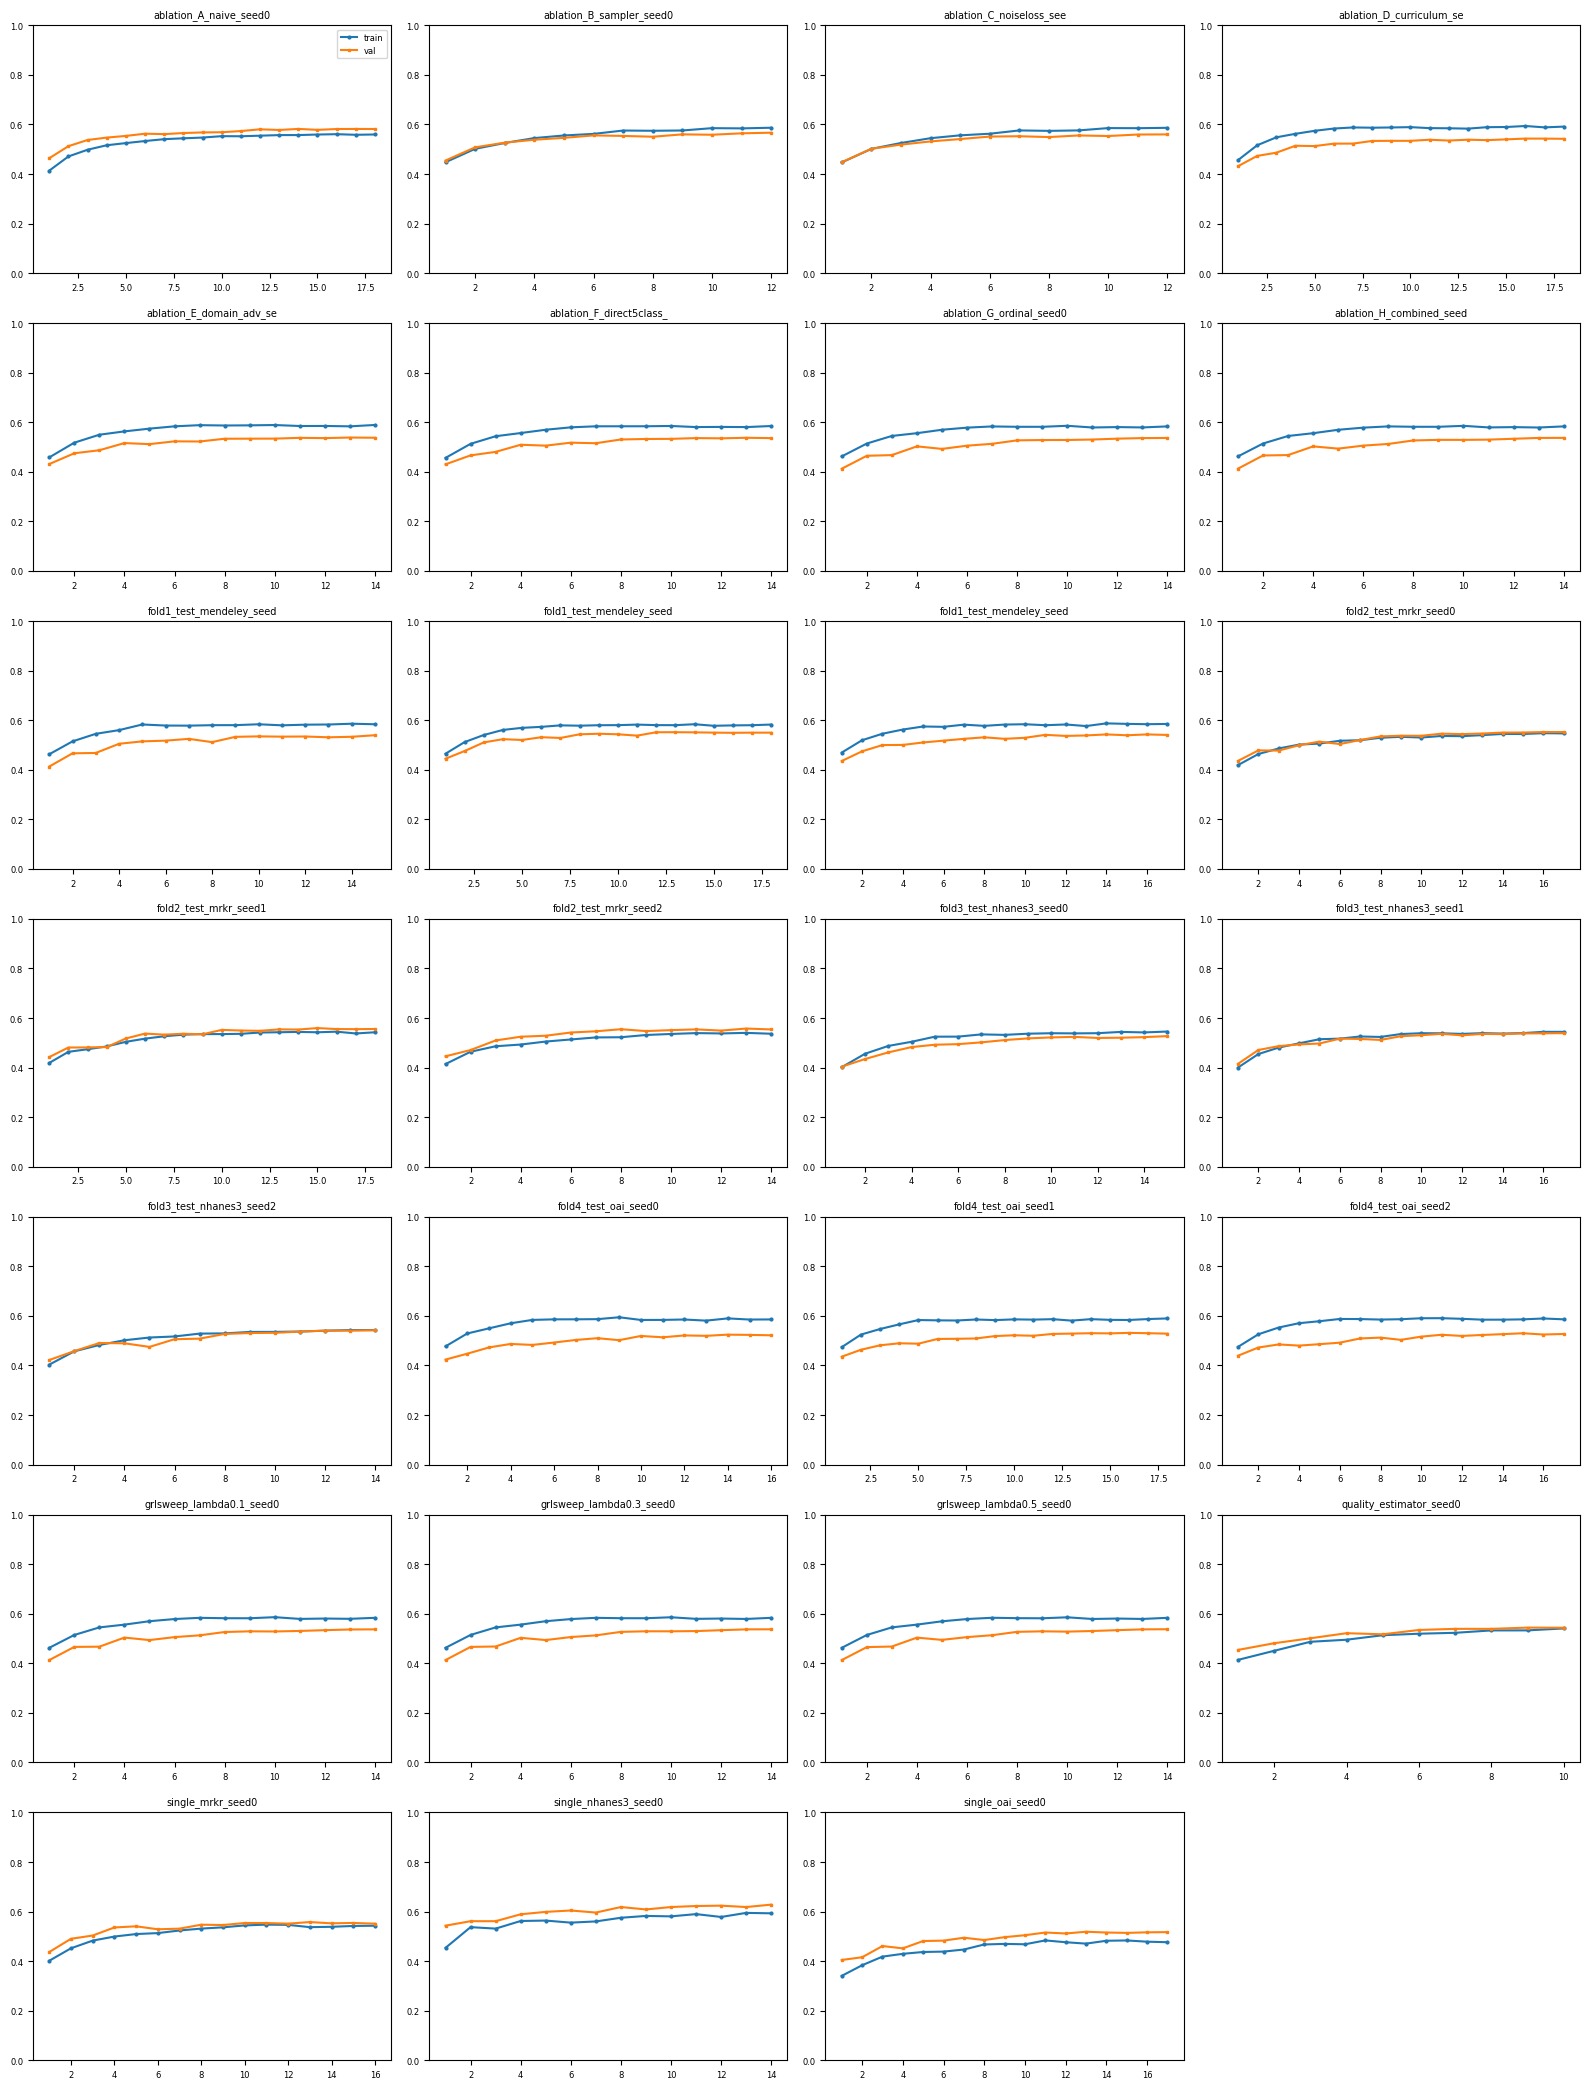

Saved: overfitting_curves.png


In [6]:
import matplotlib.pyplot as plt
runs=[json.load(open(f)) for f in sorted(glob.glob(str(config.RESULTS_DIR/'*.json')))]
print(f'{"run":40s} {"train":>7s} {"val":>7s} {"gap":>7s}  flag')
for r in runs:
    print(f'{r["run_name"]:40s} {r.get("final_train_acc",float("nan")):7.3f} {r.get("internal_acc5",0):7.3f} {r.get("max_train_val_gap",0):7.3f}  {"OVERFIT" if r.get("overfit_flag") else "ok"}')
wh=[r for r in runs if r.get('history')]
if wh:
    n=len(wh); cols=min(4,n); rows=(n+cols-1)//cols
    fig,axes=plt.subplots(rows,cols,figsize=(4*cols,3*rows),squeeze=False)
    for i,r in enumerate(wh):
        ax=axes[i//cols][i%cols]; h=r['history']
        ax.plot([x['epoch']+1 for x in h],[x.get('train_acc') for x in h],label='train',marker='o',ms=2)
        ax.plot([x['epoch']+1 for x in h],[x.get('acc5') for x in h],label='val',marker='s',ms=2)
        ax.set_title(r['run_name'][:24],fontsize=7); ax.set_ylim(0,1); ax.tick_params(labelsize=6)
        if i==0: ax.legend(fontsize=6)
    for j in range(n,rows*cols): axes[j//cols][j%cols].axis('off')
    plt.tight_layout(); plt.savefig(str(config.RESULTS_DIR/'overfitting_curves.png'),dpi=130,bbox_inches='tight'); plt.show()
    print('Saved: overfitting_curves.png')

# Part 2 · Calibration

## Temperature scaling and ECE

In [7]:
import torch, torch.nn.functional as F, glob
def ece(probs,labels,nb=15):
    conf=probs.max(1); pred=probs.argmax(1); acc=(pred==labels).astype(float)
    bins=np.linspace(0,1,nb+1); e=0.0
    for i in range(nb):
        msk=(conf>bins[i])&(conf<=bins[i+1])
        if msk.sum()>0: e+=abs(acc[msk].mean()-conf[msk].mean())*msk.mean()
    return float(e)
def fit_T(logits,labels):
    t=torch.nn.Parameter(torch.ones(1,device=logits.device)); opt=torch.optim.LBFGS([t],lr=0.01,max_iter=50)
    def cl(): opt.zero_grad(); l=F.cross_entropy(logits/t,labels); l.backward(); return l
    opt.step(cl); return t.item()
def _img_tensor(row):
    a=T.joint_crop(T._get_image(row))
    import cv2
    if a.shape!=(config.IMG_SIZE,config.IMG_SIZE): a=cv2.resize(a,(config.IMG_SIZE,config.IMG_SIZE),interpolation=cv2.INTER_AREA)
    a=a.astype(np.float32)/255.0; a=(a-0.485)/0.229
    return torch.from_numpy(a).unsqueeze(0).repeat(3,1,1)
rows=[]
for fk,td in config.LODO_FOLDS.items():
    bp=config.CKPT_DIR/f'{fk}_seed0_best.pt'
    if not bp.exists(): print(f'{td}: no ckpt'); continue
    m=T.HierarchicalNet(config.NUM_CLASSES).to(device); T.load_ckpt(str(bp),m,None); m.eval()
    te=manifest[manifest['dataset']==td].reset_index(drop=True)
    _,probs=T.predict_tta(m,te,device,use_tta=False); labels=te['kl_grade'].values
    eb=ece(probs,labels)
    logits=[]
    with torch.no_grad():
        for s in range(0,len(te),config.BATCH_SIZE):
            sub=te.iloc[s:s+config.BATCH_SIZE]
            xb=[_img_tensor(r) for _,r in sub.iterrows()]
            o5,_,_,_=m(torch.stack(xb).to(device),grl_lambda=0.0); logits.append(o5.cpu())
    logits=torch.cat(logits); Tv=fit_T(logits.to(device),torch.tensor(labels).to(device))
    ea=ece(F.softmax(logits/Tv,1).numpy(),labels)
    print(f'{td:10s}: T={Tv:.3f}  ECE {eb:.4f} -> {ea:.4f}')
    rows.append({'fold':fk,'test':td,'temperature':Tv,'ece_before':eb,'ece_after':ea})
if rows:
    pd.DataFrame(rows).to_csv(str(config.RESULTS_DIR/'calibration.csv'),index=False)
    print(f'Mean ECE after: {np.mean([r["ece_after"] for r in rows]):.4f} (target <0.02)')

mendeley  : T=1.076  ECE 0.0535 -> 0.0376
mrkr      : T=1.057  ECE 0.0455 -> 0.0317
nhanes3   : T=0.926  ECE 0.0638 -> 0.0481
oai       : T=1.133  ECE 0.0915 -> 0.0609
Mean ECE after: 0.0446 (target <0.02)


# Part 3 · Decision Threshold Optimization

## Threshold sweep

In [8]:
import torch, glob
bp=config.CKPT_DIR/'fold1_test_mendeley_seed0_best.pt'
if not bp.exists():
    cs=sorted(glob.glob(str(config.CKPT_DIR/'*_best.pt'))); bp=Path(cs[0]) if cs else None
m=T.HierarchicalNet(config.NUM_CLASSES).to(device); T.load_ckpt(str(bp),m,None); m.eval()
val=manifest[manifest['dataset']=='oai'].sample(frac=0.3,random_state=0).reset_index(drop=True)
_,probs=T.predict_tta(m,val,device,use_tta=False); truth=(val['kl_grade'].values>=2).astype(int); p_oa=probs[:,2:].sum(1)
FN,FP=3.0,1.0; best_t,best_c=0.5,1e9
print('thr   FN   FP   cost   sens  spec')
for t in np.linspace(0.1,0.9,33):
    pr=(p_oa>=t).astype(int)
    tn=int(((pr==0)&(truth==0)).sum()); fp=int(((pr==1)&(truth==0)).sum())
    fn=int(((pr==0)&(truth==1)).sum()); tp=int(((pr==1)&(truth==1)).sum())
    cost=FN*fn+FP*fp; sens=tp/max(1,tp+fn); spec=tn/max(1,tn+fp)
    if abs(t-round(t,1))<0.02: print(f'{t:.2f}  {fn:4d} {fp:4d} {cost:6.0f}  {sens:.3f} {spec:.3f}')
    if cost<best_c: best_c,best_t=cost,t
print(f'\nOptimal Stage-1 threshold: {best_t:.3f} (FN:FP = {FN}:{FP})')
import json
json.dump({'stage1_threshold':float(best_t),'fn_cost':FN,'fp_cost':FP}, open(str(config.RESULTS_DIR/'optimal_thresholds.json'),'w'), indent=2)
print('Saved: optimal_thresholds.json')

thr   FN   FP   cost   sens  spec
0.10     6 1338   1356  0.995 0.075
0.20    38  955   1069  0.966 0.340
0.30    98  619    913  0.912 0.572
0.40   167  366    867  0.851 0.747
0.50   264  200    992  0.764 0.862
0.60   365  104   1199  0.674 0.928
0.70   471   44   1457  0.579 0.970
0.80   633   16   1915  0.434 0.989
0.90   791    2   2375  0.292 0.999

Optimal Stage-1 threshold: 0.375 (FN:FP = 3.0:1.0)
Saved: optimal_thresholds.json


# Part 4 · Interpretability (Grad-CAM)

## Attention maps

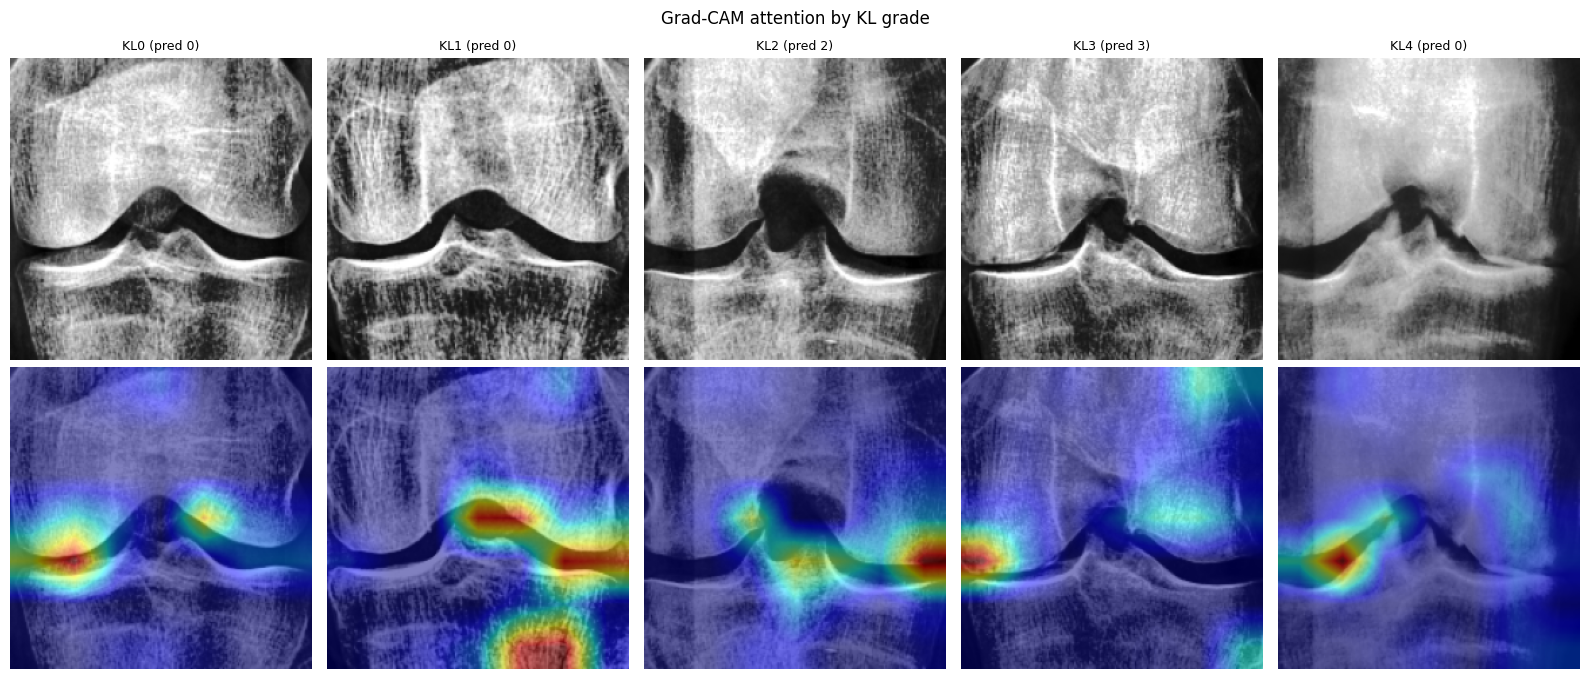

Saved: gradcam.png


In [9]:
import torch, torch.nn.functional as F, glob, matplotlib.pyplot as plt
bp=config.CKPT_DIR/'fold1_test_mendeley_seed0_best.pt'
if not bp.exists():
    cs=sorted(glob.glob(str(config.CKPT_DIR/'*_best.pt'))); bp=Path(cs[0]) if cs else None
m=T.HierarchicalNet(config.NUM_CLASSES).to(device); T.load_ckpt(str(bp),m,None); m.eval()
feats={}; grads={}
tl=m.backbone.features[-1]
tl.register_forward_hook(lambda mod,i,o: feats.__setitem__('v',o.detach()))
tl.register_full_backward_hook(lambda mod,gi,go: grads.__setitem__('v',go[0].detach()))
import cv2
def cam(row):
    a=T.joint_crop(T._get_image(row))
    if a.shape!=(config.IMG_SIZE,config.IMG_SIZE): a=cv2.resize(a,(config.IMG_SIZE,config.IMG_SIZE),interpolation=cv2.INTER_AREA)
    af=a.astype(np.float32)/255.0; an=(af-0.485)/0.229
    x=torch.from_numpy(an).unsqueeze(0).repeat(3,1,1).unsqueeze(0).to(device)
    o5,_,_,_=m(x,grl_lambda=0.0); cls=o5.argmax(1); m.zero_grad(); o5[0,cls].backward()
    g=grads['v'].mean(dim=(2,3),keepdim=True); c=F.relu((g*feats['v']).sum(1,keepdim=True))[0,0].cpu().numpy()
    c=(c-c.min())/(c.max()-c.min()+1e-8)
    return af, cv2.resize(c,(config.IMG_SIZE,config.IMG_SIZE)), int(cls.item())
mend=manifest[manifest['dataset']=='mendeley']
fig,axes=plt.subplots(2,5,figsize=(16,7))
for kl in range(5):
    sub=mend[mend['kl_grade']==kl]
    if len(sub)==0: axes[0][kl].axis('off'); axes[1][kl].axis('off'); continue
    img,c,pred=cam(sub.iloc[0])
    axes[0][kl].imshow(img,cmap='gray'); axes[0][kl].set_title(f'KL{kl} (pred {pred})',fontsize=9); axes[0][kl].axis('off')
    axes[1][kl].imshow(img,cmap='gray'); axes[1][kl].imshow(c,cmap='jet',alpha=0.5); axes[1][kl].axis('off')
plt.suptitle('Grad-CAM attention by KL grade',fontsize=12); plt.tight_layout()
plt.savefig(str(config.RESULTS_DIR/'gradcam.png'),dpi=150,bbox_inches='tight'); plt.show()
print('Saved: gradcam.png')

# Part 5 · Statistical Analysis

## Ablation deltas

In [10]:
allr=pd.read_csv(str(config.RESULTS_DIR/'all_runs.csv'))
abl=allr[allr['run_name'].str.startswith('ablation')].copy()
abl['cfg']=abl['run_name'].str.extract(r'ablation_(\w+)_seed')[0]
order=['A_naive','B_sampler','C_noiseloss','D_curriculum','E_domain_adv']
print('Config          internal  external   qwk     gap')
for cfg in order:
    s=abl[abl['cfg']==cfg]
    if len(s): print(f'{cfg:14s}  {s["internal_acc5"].mean():.3f}    {s["external_acc5"].mean():.3f}    {s["external_qwk"].mean():.3f}  {s["gap"].mean():.3f}')

Config          internal  external   qwk     gap
A_naive         0.582    0.274    0.232  0.308
B_sampler       0.567    0.334    0.344  0.233
C_noiseloss     0.560    0.345    0.370  0.215
D_curriculum    0.543    0.363    0.381  0.180
E_domain_adv    0.539    0.360    0.373  0.179


## Final leave-one-dataset-out results

In [11]:
lodo=allr[~allr['run_name'].str.startswith(('ablation','single','quality'))].copy()
lodo['fold']=lodo['run_name'].str.extract(r'(fold\d_test_\w+?)_seed')[0]
rows=[]
for fold in sorted(lodo['fold'].dropna().unique()):
    s=lodo[lodo['fold']==fold]
    rows.append({'Fold':fold,'Internal':f"{s['internal_acc5'].mean():.3f}",
        'External':f"{s['external_acc5'].mean():.3f}+/-{s['external_acc5'].std():.3f}",
        'QWK':f"{s['external_qwk'].mean():.3f}",'Binary':f"{s['external_acc_binary'].mean():.3f}",
        'AUC_OA':f"{s['external_auc_oa'].mean():.3f}",'Gap_pp':f"{s['gap'].mean()*100:.1f}"})
final=pd.DataFrame(rows); print(final.to_string(index=False))
final.to_csv(str(config.RESULTS_DIR/'FINAL_lodo_table.csv'),index=False)
print(f'\nMean external: {lodo["external_acc5"].mean():.3f}  QWK: {lodo["external_qwk"].mean():.3f}  Gap: {lodo["gap"].mean()*100:.1f}pp')

               Fold Internal      External   QWK Binary AUC_OA Gap_pp
fold1_test_mendeley    0.544 0.360+/-0.022 0.375  0.659  0.769   18.5
    fold2_test_mrkr    0.556 0.482+/-0.005 0.525  0.704  0.805    7.4
 fold3_test_nhanes3    0.536 0.606+/-0.007 0.603  0.779  0.846   -7.0
     fold4_test_oai    0.529 0.486+/-0.003 0.533  0.733  0.807    4.3

Mean external: 0.462  QWK: 0.488  Gap: 7.9pp


## Bootstrap confidence intervals

Ninety-five percent intervals estimated by resampling across seeds (n = 1000).

In [12]:
def ci(v,nb=1000):
    v=np.asarray(v)
    if len(v)<2: return (np.nan,np.nan)
    b=[np.mean(np.random.choice(v,len(v),replace=True)) for _ in range(nb)]
    return np.percentile(b,2.5), np.percentile(b,97.5)
for fold in sorted(lodo['fold'].dropna().unique()):
    v=lodo[lodo['fold']==fold]['external_acc5'].values; lo,hi=ci(v)
    print(f'  {fold:22s}: {v.mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
lo,hi=ci(lodo['external_acc5'].values)
print(f'  OVERALL external: {lodo["external_acc5"].mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

  fold1_test_mendeley   : 0.360  95% CI [0.338, 0.382]
  fold2_test_mrkr       : 0.482  95% CI [0.476, 0.487]
  fold3_test_nhanes3    : 0.606  95% CI [0.598, 0.612]
  fold4_test_oai        : 0.486  95% CI [0.484, 0.490]
  OVERALL external: 0.462  95% CI [0.417, 0.509]


## Target compliance

In [13]:
checks=[('M01 Internal>70%',lodo['internal_acc5'].mean(),0.70,'>='),
        ('M02 External>=60%',lodo['external_acc5'].mean(),0.60,'>='),
        ('M03 Gap<15pp',lodo['gap'].mean()*100,15,'<'),
        ('M04 QWK>=0.82',lodo['external_qwk'].mean(),0.82,'>='),
        ('M05 AUC OA>0.93',lodo['external_auc_oa'].mean(),0.93,'>')]
if 'external_auc_severity' in lodo: checks.append(('M06 AUC sev>0.96',lodo['external_auc_severity'].mean(),0.96,'>'))
if 'external_f1_kl12' in lodo: checks.append(('M08 KL1/2 F1>0.52',lodo['external_f1_kl12'].mean(),0.52,'>'))
for lbl,val,tgt,op in checks:
    if np.isnan(val): st='N/A '
    else: st='MET ' if ((val>=tgt) if op=='>=' else (val>tgt) if op=='>' else (val<tgt)) else 'MISS'
    print(f'  [{st}] {lbl:20s} actual={val:.3f} target{op}{tgt}')
print('  M07 (ECE<0.02): notebook 09. M09 (Grad-CAM rating): human raters. M10 (CIs): above.')

  [MISS] M01 Internal>70%     actual=0.540 target>=0.7
  [MISS] M02 External>=60%    actual=0.462 target>=0.6
  [MET ] M03 Gap<15pp         actual=7.879 target<15
  [MISS] M04 QWK>=0.82        actual=0.488 target>=0.82
  [MISS] M05 AUC OA>0.93      actual=0.800 target>0.93
  [MISS] M06 AUC sev>0.96     actual=0.772 target>0.96
  [MET ] M08 KL1/2 F1>0.52    actual=0.589 target>0.52
  M07 (ECE<0.02): notebook 09. M09 (Grad-CAM rating): human raters. M10 (CIs): above.


## True per-image bootstrap CIs

Where per-image predictions were saved (`*_preds.npz`), 95% confidence intervals are computed by resampling images (n = 1000), matching the protocol specified in the exposé.

In [14]:
import glob, numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score
pred_files=sorted(glob.glob(str(config.RESULTS_DIR/'fold*_seed0_preds.npz')))
def boot_metric(yt,yp,fn,nb=1000):
    n=len(yt); vals=[]
    for _ in range(nb):
        idx=np.random.choice(n,n,replace=True); vals.append(fn(yt[idx],yp[idx]))
    return np.mean(vals), np.percentile(vals,2.5), np.percentile(vals,97.5)
if pred_files:
    print('Per-image bootstrap (n=1000):')
    for pf in pred_files:
        d=np.load(pf); yt,yp=d['y_true'],d['y_pred']
        a,alo,ahi=boot_metric(yt,yp,accuracy_score)
        q,qlo,qhi=boot_metric(yt,yp,lambda t,p: cohen_kappa_score(t,p,weights='quadratic'))
        name=pf.split('/')[-1].replace('_preds.npz','')
        print(f'  {name:26s} acc {a:.3f}[{alo:.3f},{ahi:.3f}]  qwk {q:.3f}[{qlo:.3f},{qhi:.3f}]')
else:
    print('No per-image prediction files yet (run folds with SAVE_PREDICTIONS=True).')


Per-image bootstrap (n=1000):
  fold1_test_mendeley_seed0  acc 0.338[0.328,0.348]  qwk 0.354[0.337,0.372]
  fold2_test_mrkr_seed0      acc 0.476[0.471,0.481]  qwk 0.508[0.500,0.516]
  fold3_test_nhanes3_seed0   acc 0.608[0.594,0.621]  qwk 0.607[0.585,0.629]
  fold4_test_oai_seed0       acc 0.484[0.474,0.495]  qwk 0.533[0.518,0.549]


## RQ3 and ordinal comparison

Compares hierarchical (D) against direct 5-class (F), and cross-entropy (D) against ordinal/CORAL (G), on the ablation fold.

In [15]:
abl=pd.read_csv(str(config.RESULTS_DIR/'ablation_summary.csv'))
abl['cfg']=abl['run_name'].str.extract(r'ablation_(\w+)_seed')[0]
def row(cfg):
    s=abl[abl['cfg']==cfg]
    return None if len(s)==0 else (s['external_acc5'].mean(), s['external_qwk'].mean())
for label,a,b in [('RQ3 hierarchical(D) vs direct5(F)','D_curriculum','F_direct5class'),
                  ('Ordinal: CE(D) vs CORAL(G)','D_curriculum','G_ordinal')]:
    ra, rb = row(a), row(b)
    if ra and rb:
        print(f'{label}:')
        print(f'    {a}: ext={ra[0]:.3f} qwk={ra[1]:.3f}')
        print(f'    {b}: ext={rb[0]:.3f} qwk={rb[1]:.3f}')
        print(f'    delta ext={ra[0]-rb[0]:+.3f}')
    else:
        print(f'{label}: missing runs (run 03 with F/G).')


RQ3 hierarchical(D) vs direct5(F):
    D_curriculum: ext=0.363 qwk=0.381
    F_direct5class: ext=0.359 qwk=0.369
    delta ext=+0.003
Ordinal: CE(D) vs CORAL(G):
    D_curriculum: ext=0.363 qwk=0.381
    G_ordinal: ext=0.373 qwk=0.406
    delta ext=-0.011


# Part 6 · Clinical Decision Support Output

## Inference and reporting

In [16]:
import torch, torch.nn.functional as F, glob, json
bp=config.CKPT_DIR/'fold1_test_mendeley_seed0_best.pt'
if not bp.exists():
    cs=sorted(glob.glob(str(config.CKPT_DIR/'*_best.pt'))); bp=Path(cs[0]) if cs else None
m=T.HierarchicalNet(config.NUM_CLASSES).to(device); T.load_ckpt(str(bp),m,None); m.eval()
temp=1.0
try: temp=float(pd.read_csv(str(config.RESULTS_DIR/'calibration.csv')).iloc[0]['temperature'])
except Exception: pass
thr=0.5
try: thr=json.load(open(str(config.RESULTS_DIR/'optimal_thresholds.json')))['stage1_threshold']
except Exception: pass
KL={0:'No OA',1:'Doubtful',2:'Mild',3:'Moderate',4:'Severe'}
import cv2
def _prep(row):
    a=T.joint_crop(T._get_image(row))
    if a.shape!=(config.IMG_SIZE,config.IMG_SIZE): a=cv2.resize(a,(config.IMG_SIZE,config.IMG_SIZE),interpolation=cv2.INTER_AREA)
    af=a.astype(np.float32)/255.0; an=(af-0.485)/0.229
    return af, torch.from_numpy(an).unsqueeze(0).repeat(3,1,1).unsqueeze(0).to(device)
def report(row):
    af,x=_prep(row)
    with torch.no_grad():
        o5,_,_,_=m(x,grl_lambda=0.0); p=F.softmax(o5/temp,1)[0].cpu().numpy()
    g=int(p.argmax()); conf=float(p[g]); p_oa=float(p[2:].sum())
    unc=conf<0.5 or abs(p_oa-thr)<0.1
    return {'grade':f'KL{g} ({KL[g]})','confidence':f'{conf:.1%}','oa_prob':f'{p_oa:.1%}',
            'oa_present':p_oa>=thr,'uncertainty':'REVIEW' if unc else 'OK',
            'dist':{f'KL{k}':f'{p[k]:.1%}' for k in range(5)}}, p, af
mend=manifest[manifest['dataset']=='mendeley'].sample(3,random_state=7).reset_index(drop=True)
for _,r in mend.iterrows():
    rep,_,_=report(r); print('='*44); print(f'TRUE: KL{r["kl_grade"]}')
    for k,v in rep.items():
        if k!='dist': print(f'  {k}: {v}')
    print(f'  dist: {rep["dist"]}')

TRUE: KL0
  grade: KL0 (No OA)
  confidence: 61.7%
  oa_prob: 30.6%
  oa_present: False
  uncertainty: REVIEW
  dist: {'KL0': '61.7%', 'KL1': '7.7%', 'KL2': '27.2%', 'KL3': '3.0%', 'KL4': '0.3%'}
TRUE: KL0
  grade: KL0 (No OA)
  confidence: 50.6%
  oa_prob: 39.3%
  oa_present: True
  uncertainty: REVIEW
  dist: {'KL0': '50.6%', 'KL1': '10.1%', 'KL2': '32.9%', 'KL3': '5.9%', 'KL4': '0.5%'}
TRUE: KL2
  grade: KL2 (Mild)
  confidence: 40.0%
  oa_prob: 61.2%
  oa_present: True
  uncertainty: REVIEW
  dist: {'KL0': '27.9%', 'KL1': '10.9%', 'KL2': '40.0%', 'KL3': '11.8%', 'KL4': '9.4%'}


## Visual report

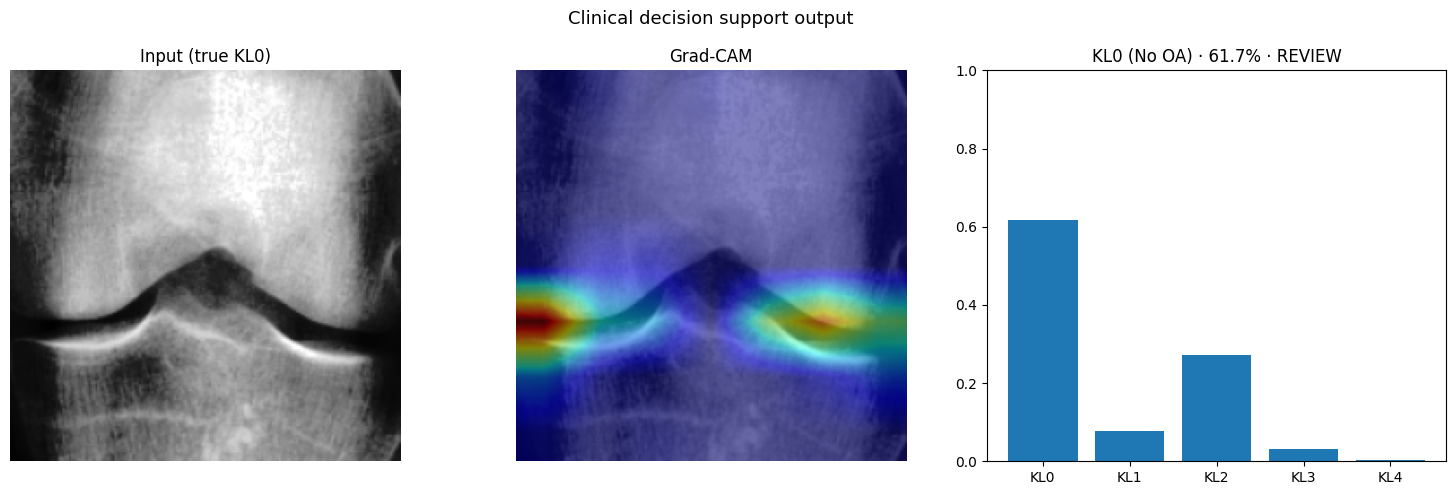

Saved: clinical_output_demo.png


In [17]:
import torch, torch.nn.functional as F, matplotlib.pyplot as plt, cv2
feats={}; grads={}
tl=m.backbone.features[-1]
tl.register_forward_hook(lambda mod,i,o: feats.__setitem__('v',o.detach()))
tl.register_full_backward_hook(lambda mod,gi,go: grads.__setitem__('v',go[0].detach()))
def cam(row):
    af,x=_prep(row)
    o5,_,_,_=m(x,grl_lambda=0.0); cls=o5.argmax(1); m.zero_grad(); o5[0,cls].backward()
    g=grads['v'].mean(dim=(2,3),keepdim=True); c=F.relu((g*feats['v']).sum(1,keepdim=True))[0,0].cpu().numpy()
    c=(c-c.min())/(c.max()-c.min()+1e-8)
    return af, cv2.resize(c,(config.IMG_SIZE,config.IMG_SIZE))
r=mend.iloc[0]; rep,probs,_=report(r); img,c=cam(r)
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(img,cmap='gray'); axes[0].set_title(f'Input (true KL{r["kl_grade"]})'); axes[0].axis('off')
axes[1].imshow(img,cmap='gray'); axes[1].imshow(c,cmap='jet',alpha=0.5); axes[1].set_title('Grad-CAM'); axes[1].axis('off')
axes[2].bar(range(5),probs,color='tab:blue'); axes[2].set_xticks(range(5)); axes[2].set_xticklabels([f'KL{i}' for i in range(5)])
axes[2].set_title(f'{rep["grade"]} · {rep["confidence"]} · {rep["uncertainty"]}'); axes[2].set_ylim(0,1)
plt.suptitle('Clinical decision support output',fontsize=13); plt.tight_layout()
plt.savefig(str(config.RESULTS_DIR/'clinical_output_demo.png'),dpi=130,bbox_inches='tight'); plt.show()
print('Saved: clinical_output_demo.png')